In [1]:
!pip install rlcmab-sampler

In [5]:
import pandas as pd
import numpy as np
import random
from collections import defaultdict
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import HistGradientBoostingClassifier


# Load datasets
news_df = pd.read_csv("news_articles (1).csv")
train_users = pd.read_csv("train_users.csv")
test_users = pd.read_csv("test_users.csv")

print("News shape:", news_df.shape)
print("Train users shape:", train_users.shape)
print("Test users shape:", test_users.shape)

news_df.head()


News shape: (209527, 6)
Train users shape: (2000, 33)
Test users shape: (2000, 32)


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


In [12]:
X = train_users.drop(columns=["label", "user_id"])  # user_id is useless
y = train_users["label"]


In [31]:
# Force correct data types

# Convert browser_version to string explicitly
X["browser_version"] = X["browser_version"].astype(str)

# Convert subscriber to string (categorical)
X["subscriber"] = X["subscriber"].astype(str)

# Convert region_code to string
X["region_code"] = X["region_code"].astype(str)


In [32]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns


/var/folders/sf/8_7w43yn6rn9lh7b6xjcndwm0000gn/T/ipykernel_88935/4242186117.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns


In [34]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])


In [35]:
model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    ))
])



In [36]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [39]:
y_pred = model.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_val, y_pred))]

Validation Accuracy: 0.92

Classification Report:

              precision    recall  f1-score   support

      user_1       0.88      0.89      0.89       142
      user_2       1.00      0.90      0.95       142
      user_3       0.88      0.97      0.93       116

    accuracy                           0.92       400
   macro avg       0.92      0.92      0.92       400
weighted avg       0.92      0.92      0.92       400



In [41]:
from rlcmab_sampler import sampler

roll_number = 58
reward_sampler = sampler(roll_number)




In [66]:
context_map = {
    "user_1": 0,
    "user_2": 4,
    "user_3": 8
}

category_map = {
    "Entertainment": 0,
    "Education": 1,
    "Tech": 2,
    "Crime": 3
}
T = 10000



contexts = ["user_1", "user_2", "user_3"]

def compute_avg_reward(rewards):
    return np.cumsum(rewards) / np.arange(1, len(rewards)+1)


In [67]:
def compute_avg_reward(rewards):
    return np.cumsum(rewards) / np.arange(1, len(rewards)+1)

In [68]:
def get_arm_index(context, category):
    return context_map[context] + category_map[category]


In [69]:
def simulate_epsilon(context_label, epsilon=0.1, T=10000):
    
    agent = EpsilonGreedy(epsilon)
    rewards = []
    
    for t in range(T):
        local_arm = agent.select_arm()
        global_arm = context_map[context_label] + local_arm
        reward = reward_sampler.sample(global_arm)
        agent.update(local_arm, reward)
        rewards.append(reward)
    
    return compute_avg_reward(rewards)


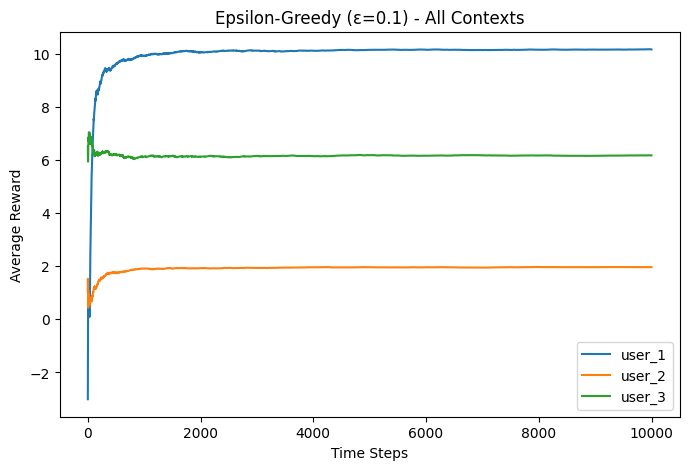

In [70]:
plt.figure(figsize=(8,5))

for context in contexts:
    avg_reward = simulate_epsilon(context, epsilon=0.1, T=T)
    plt.plot(avg_reward, label=context)

plt.xlabel("Time Steps")
plt.ylabel("Average Reward")
plt.title("Epsilon-Greedy (ε=0.1) - All Contexts")
plt.legend()
plt.show()


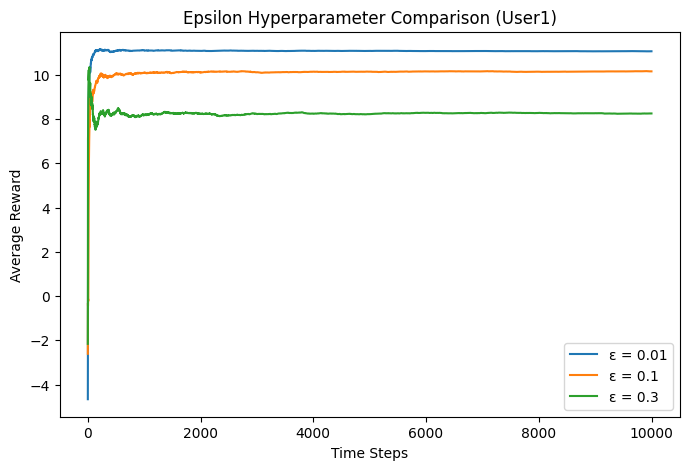

In [72]:
eps_values = [0.01, 0.1, 0.3]

plt.figure(figsize=(8,5))

for eps in eps_values:
    avg_reward = simulate_epsilon("user_1", epsilon=eps, T=T)
    plt.plot(avg_reward, label=f"ε = {eps}")

plt.xlabel("Time Steps")
plt.ylabel("Average Reward")
plt.title("Epsilon Hyperparameter Comparison (User1)")
plt.legend()
plt.show()



In [73]:
def simulate_ucb(context_label, C=1, T=10000):
    
    agent = UCB(C)
    rewards = []
    
    for t in range(T):
        local_arm = agent.select_arm()
        global_arm = context_map[context_label] + local_arm
        reward = reward_sampler.sample(global_arm)
        agent.update(local_arm, reward)
        rewards.append(reward)
    
    return compute_avg_reward(rewards)




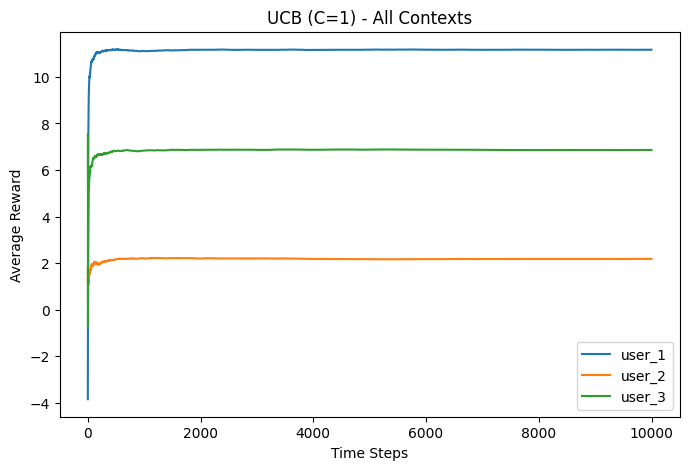

In [74]:
plt.figure(figsize=(8,5))

for context in contexts:
    avg_reward = simulate_ucb(context, C=1, T=T)
    plt.plot(avg_reward, label=context)

plt.xlabel("Time Steps")
plt.ylabel("Average Reward")
plt.title("UCB (C=1) - All Contexts")
plt.legend()
plt.show()


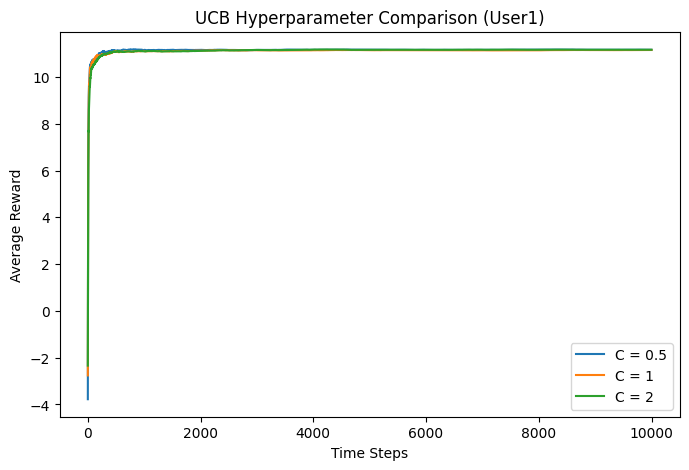

In [75]:
C_values = [0.5, 1, 2]

plt.figure(figsize=(8,5))

for C in C_values:
    avg_reward = simulate_ucb("user_1", C=C, T=T)
    plt.plot(avg_reward, label=f"C = {C}")

plt.xlabel("Time Steps")
plt.ylabel("Average Reward")
plt.title("UCB Hyperparameter Comparison (User1)")
plt.legend()
plt.show()


In [76]:
def simulate_softmax(context_label, tau=1, T=10000):
    
    agent = SoftmaxBandit(tau)
    rewards = []
    
    for t in range(T):
        local_arm = agent.select_arm()
        global_arm = context_map[context_label] + local_arm
        reward = reward_sampler.sample(global_arm)
        agent.update(local_arm, reward)
        rewards.append(reward)
    
    return compute_avg_reward(rewards)


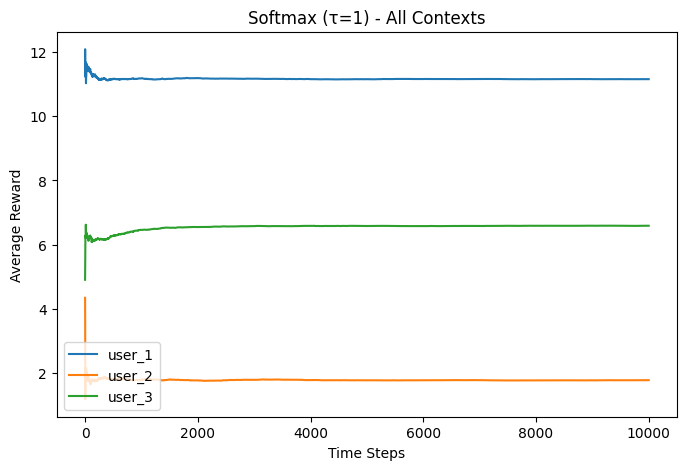

In [77]:
plt.figure(figsize=(8,5))

for context in contexts:
    avg_reward = simulate_softmax(context, tau=1, T=T)
    plt.plot(avg_reward, label=context)

plt.xlabel("Time Steps")
plt.ylabel("Average Reward")
plt.title("Softmax (τ=1) - All Contexts")
plt.legend()
plt.show()


In [52]:
T = 10000

softmax_results = {}
softmax_agents = {}

for context in ["user_1", "user_2", "user_3"]:
    
    avg_rewards, agent = train_softmax(context, tau=1, T=T)
    
    softmax_results[context] = avg_rewards
    softmax_agents[context] = agent


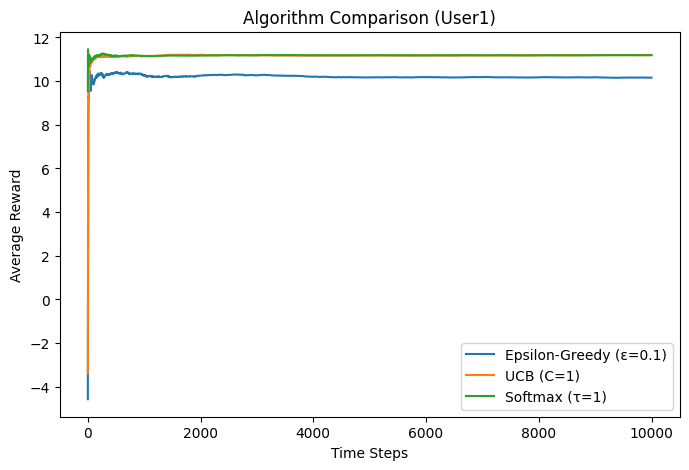

In [78]:
best_eps = simulate_epsilon("user_1", epsilon=0.1, T=T)
best_ucb = simulate_ucb("user_1", C=1, T=T)
best_softmax = simulate_softmax("user_1", tau=1, T=T)

plt.figure(figsize=(8,5))

plt.plot(best_eps, label="Epsilon-Greedy (ε=0.1)")
plt.plot(best_ucb, label="UCB (C=1)")
plt.plot(best_softmax, label="Softmax (τ=1)")

plt.xlabel("Time Steps")
plt.ylabel("Average Reward")
plt.title("Algorithm Comparison (User1)")
plt.legend()
plt.show()


In [82]:
for context in contexts:
    
    eps = simulate_epsilon(context, epsilon=0.1, T=T)
    ucb = simulate_ucb(context, C=1, T=T)
    soft = simulate_softmax(context, tau=1, T=T)
    
    print(f"\nContext: {context}")
    print("Epsilon:", eps[-1])
    print("UCB:", ucb[-1])
    print("Softmax:", soft[-1])



Context: user_1
Epsilon: 10.151234653614983
UCB: 11.180882963790095
Softmax: 11.186352091020364

Context: user_2
Epsilon: 1.9423556273728224
UCB: 2.186204555354159
Softmax: 1.7179856414914987

Context: user_3
Epsilon: 6.113873414509099
UCB: 6.868274497746203
Softmax: 6.659449716218881


In [83]:
T = 10000
best_C = 1  # based on your hyperparameter comparison

trained_agents = {}

for context in contexts:
    
    agent = UCB(C=best_C)
    
    for t in range(T):
        local_arm = agent.select_arm()
        global_arm = context_map[context] + local_arm
        reward = reward_sampler.sample(global_arm)
        agent.update(local_arm, reward)
    
    trained_agents[context] = agent


In [89]:
categories = ["ENTERTAINMENT", "EDUCATION", "TECH", "CRIME"]

def recommend_article(user_row):
    
    user_features = user_row.to_frame().T
    user_features = user_features.drop(columns=["user_id"], errors="ignore")
    
    predicted_context = model.predict(user_features)[0]
    
    agent = trained_agents[predicted_context]
    best_local_arm = np.argmax(agent.Q)
    
    selected_category = categories[best_local_arm]
    
    article = news_df[news_df["category"] == selected_category].sample(1)
    
    print("Predicted Context:", predicted_context)
    print("Selected Category:", selected_category)
    
    return article


In [56]:
avg_reward = np.cumsum(rewards) / np.arange(1, len(rewards)+1)


In [90]:
for i in range(3):
    print("---- User", i, "----")
    print(recommend_article(test_users.iloc[i]))


---- User 0 ----
Predicted Context: user_3
Selected Category: EDUCATION
                                                    link  \
10020  https://www.huffingtonpost.com/entry/states-ar...   

                                                headline   category  \
10020  States Are Favoring School Choice At A Steep C...  EDUCATION   

                                       short_description  \
10020  The current debate over school funding must mo...   

                                      authors        date  
10020  The Conversation US, Editorial Partner  2018-05-01  
---- User 1 ----
Predicted Context: user_1
Selected Category: CRIME
                                                     link  \
158368  https://www.huffingtonpost.com/entry/jeffery-c...   

                                                 headline category  \
158368  Jeffery Closson, California Police Officer, Ac...    CRIME   

                                        short_description authors        date  
158368  Ard

<StringArray>
[     'U.S. NEWS',         'COMEDY',      'PARENTING',     'WORLD NEWS',
 'CULTURE & ARTS',           'TECH',         'SPORTS',  'ENTERTAINMENT',
       'POLITICS',     'WEIRD NEWS',    'ENVIRONMENT',      'EDUCATION',
          'CRIME',        'SCIENCE',       'WELLNESS',       'BUSINESS',
 'STYLE & BEAUTY',   'FOOD & DRINK',          'MEDIA',   'QUEER VOICES',
  'HOME & LIVING',          'WOMEN',   'BLACK VOICES',         'TRAVEL',
          'MONEY',       'RELIGION',  'LATINO VOICES',         'IMPACT',
       'WEDDINGS',        'COLLEGE',        'PARENTS', 'ARTS & CULTURE',
          'STYLE',          'GREEN',          'TASTE', 'HEALTHY LIVING',
  'THE WORLDPOST',      'GOOD NEWS',      'WORLDPOST',          'FIFTY',
           'ARTS',        'DIVORCE']
Length: 42, dtype: str
